In [1]:
library(Giotto)
library(data.table)
library(data.table)
library(Matrix)


In [2]:
df <- read.table("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/st_expression.tsv", header=TRUE, sep="\t", check.names=FALSE)
colnames(df) <- ifelse(grepl("^[0-9]+$", colnames(df)), paste0("X", colnames(df)), colnames(df))
write.table(df, file='/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/st_expressionx.tsv',sep='\t',quote = F,row.names = F)

In [3]:
library(Giotto)
# 1. Directly from the file paths
path_to_matrix = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/st_expressionx.tsv"
path_to_locations =  "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatial_coords.tsv"
my_python_path <- "/home/qyyuan/anaconda3/envs/SpatialDWLS/bin/python"
my_instructions <- createGiottoInstructions(
    python_path = my_python_path
)
my_giotto_object = createGiottoObject(raw_exprs = path_to_matrix,
                  spatial_locs = path_to_locations,instructions = my_instructions)


 external python path provided and will be used 
Consider to install these (optional) packages to run all possible Giotto commands for spatial analyses:  scran MAST smfishHmrf trendsceek SPARK multinet RTriangle FactoMiner
 Giotto does not automatically install all these packages as they are not absolutely required and this reduces the number of dependencies

In [4]:
my_giotto_object <- filterGiotto(gobject = my_giotto_object,
             expression_threshold = 0.01,
             gene_det_in_min_cells = 1,
             min_det_genes_per_cell = 1)

In [5]:
my_giotto_object <- normalizeGiotto(gobject = my_giotto_object, scalefactor = 60, verbose = T)



 first scale genes and then cells 


return_plot = TRUE and return_gobject = TRUE 

          plot will not be returned to object, but can still be saved with save_plot = TRUE or manually 


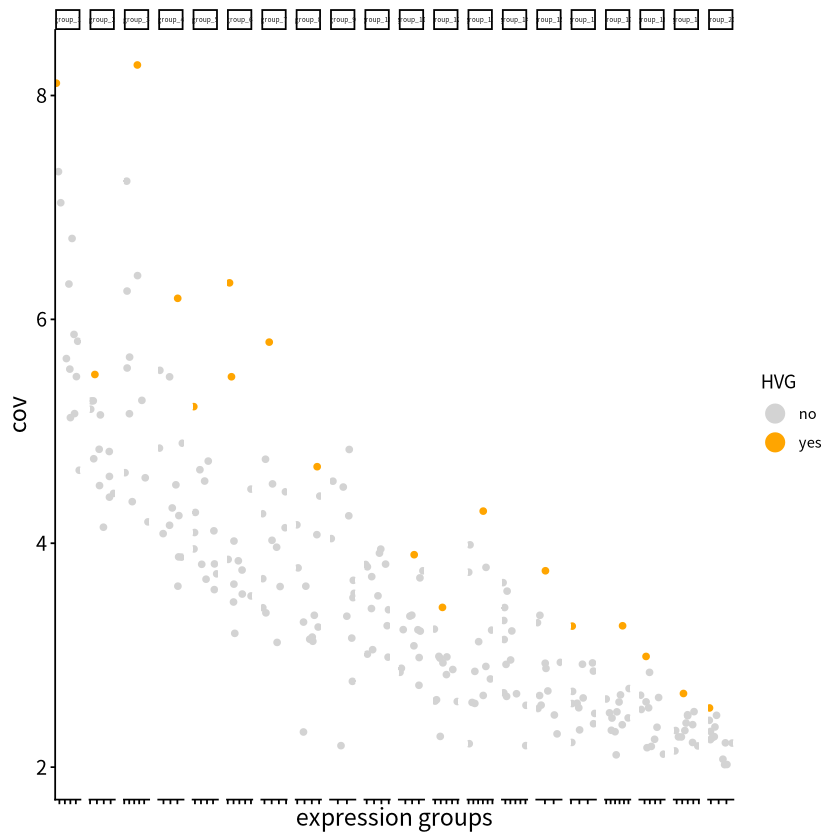

In [6]:
my_giotto_object <- calculateHVG(gobject = my_giotto_object)

hvg  was found in the gene metadata information and will be used to select highly variable genes 


Warning message in runPCA_prcomp_irlba(x = t_giotto(expr_values), center = center, :
“ncp >= minimum dimension of x, will be set to minimum dimension of x - 1”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“did not converge--results might be invalid!; try increasing work or maxit”


PCA with name:  pca  already exists and will be used for the screeplot 


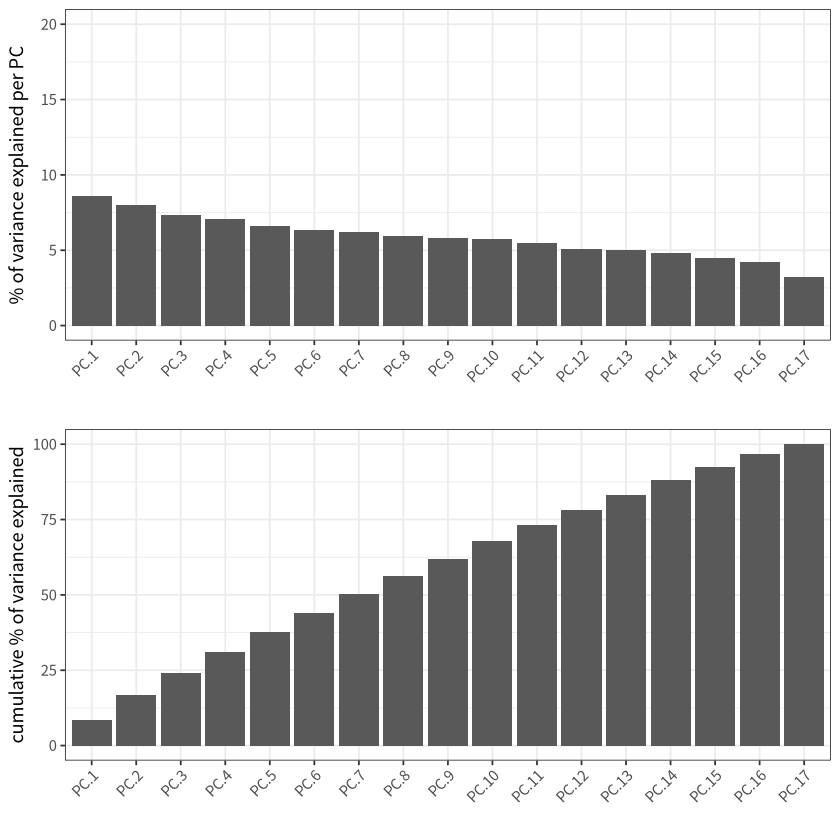

using 'jackstraw' to identify significant PCs If used in published research, please cite:
  Neo Christopher Chung and John D. Storey (2014).
  'Statistical significance of variables driving systematic variation in high-dimensional data. Bioinformatics

Estimating a number of significant principal component: 



1  2  3  4  5  6  7  8  9  10  number of estimated significant components:  NA 


Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


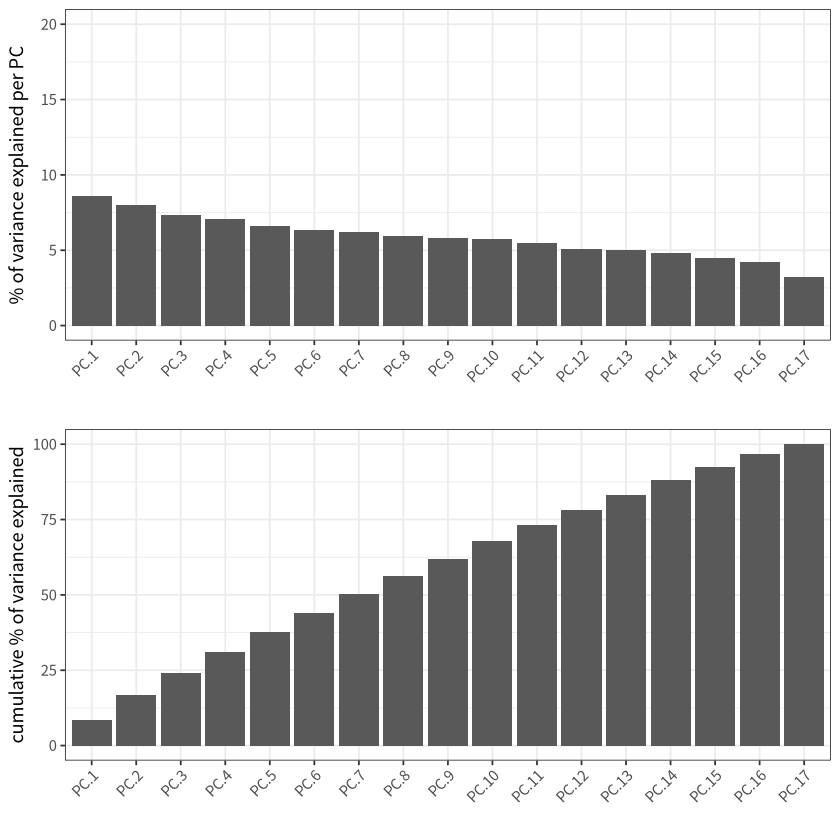

Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


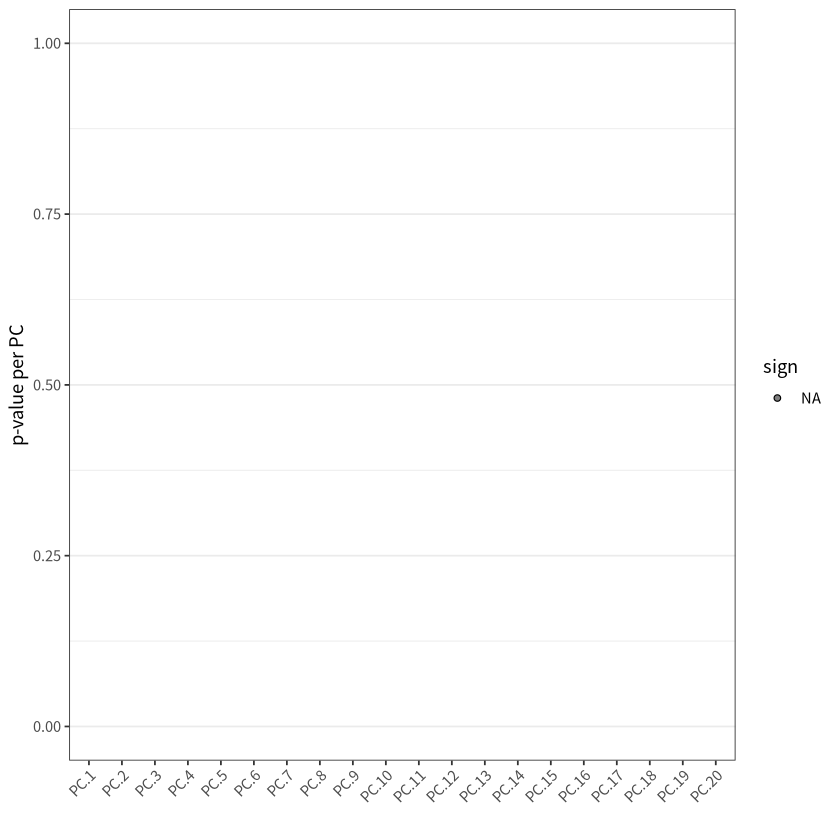

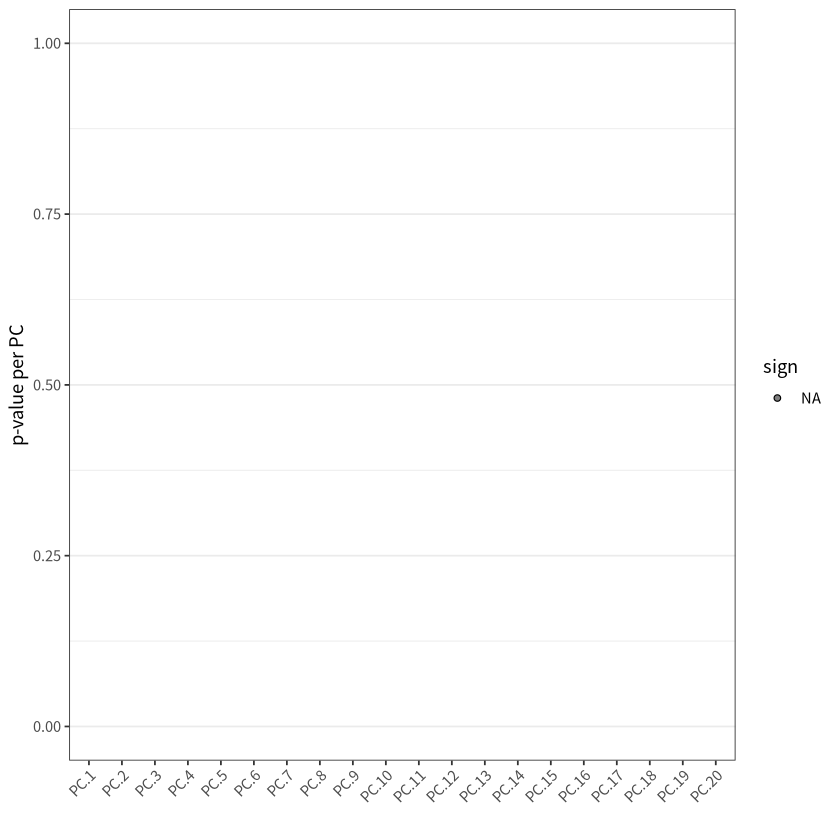

In [7]:
# Run PCA
my_giotto_object <- runPCA(gobject = my_giotto_object)

# Identify most informative principal components
screePlot(my_giotto_object, ncp = 20)
jackstrawPlot(my_giotto_object, ncp = 20)

In [8]:
# UMAP
my_giotto_object <- runUMAP(my_giotto_object, dimensions_to_use = 1:5)
#plotUMAP(gobject = my_giotto_object)

# TSNE
#my_giotto_object <- runtSNE(my_giotto_object, dimensions_to_use = 1:5)
#plotTSNE(gobject = my_giotto_object)



In [9]:
my_giotto_object = doHclust(my_giotto_object, k = 4, name = 'hier_clus')


In [10]:
single_cell_DT = fread('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/sc_expression.tsv')
single_cell_matrix = Giotto:::dt_to_matrix(single_cell_DT)
single_cell_matrix[1:4, 1:4]



4 x 4 sparse Matrix of class "dgCMatrix"
              100047181052654346224529175853339022386
1700022I11Rik                                       .
1810046K07Rik                                       .
5031425F14Rik                                       .
5730522E02Rik                                       .
              100144987682981782100923292757524648699
1700022I11Rik                                       .
1810046K07Rik                                       .
5031425F14Rik                                       .
5730522E02Rik                                       .
              100267747580756240041023704492842942950
1700022I11Rik                                       .
1810046K07Rik                                       .
5031425F14Rik                                       .
5730522E02Rik                                       .
              100380418078413692631351412383892166094
1700022I11Rik                                       .
1810046K07Rik                            

In [11]:
# Single cell annotation vector
cell_annotations = read.table(file = '/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/cell_type_labels.tsv',  sep = "\t", header= TRUE)


In [12]:
cell_annotations = as.vector(cell_annotations$CellType)
cell_annotations[1:10]
# 1.2 create rank matrix
rank_matrix = makeSignMatrixRank(sc_matrix = single_cell_matrix, sc_cluster_ids = cell_annotations)
# 1.3 enrichment test with RANK
# runSpatialEnrich() can also be used as a wrapper for all currently provided enrichment options
my_giotto_object = runRankEnrich(gobject = my_giotto_object, sign_matrix = rank_matrix)



[1] "Oligo"   "VLMC"    "Astro"   "L4_5_IT" "L4_5_IT" "L5_IT"   "VLMC"   
 [8] "L4_5_IT" "L2_3_IT" "L4_5_IT"

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Giotto package.
  Please report the issue at <https://github.com/RubD/Giotto/issues>.”


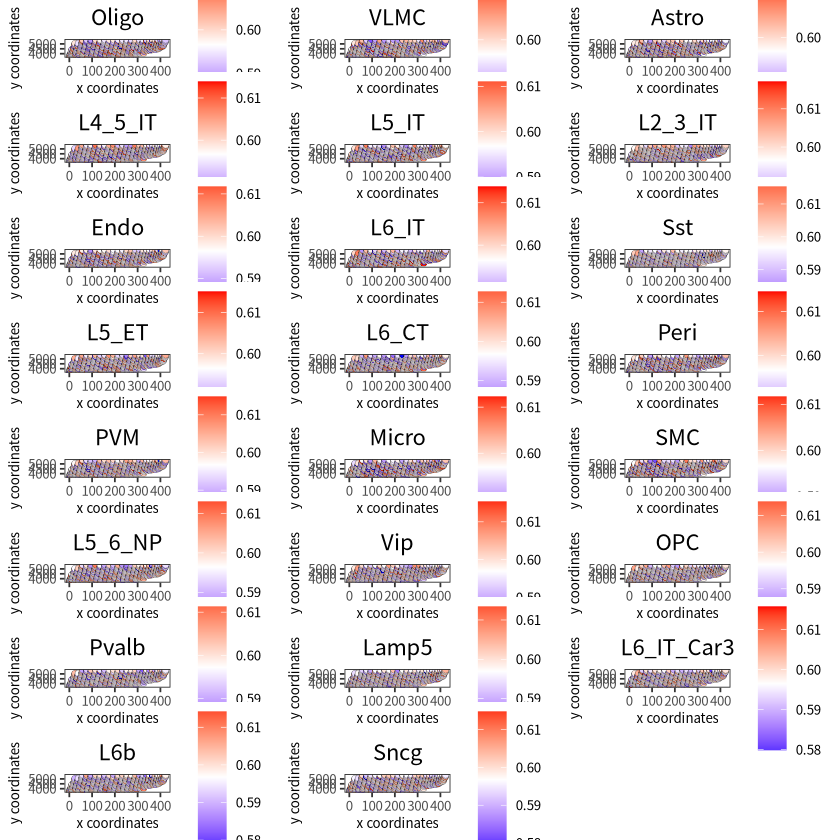

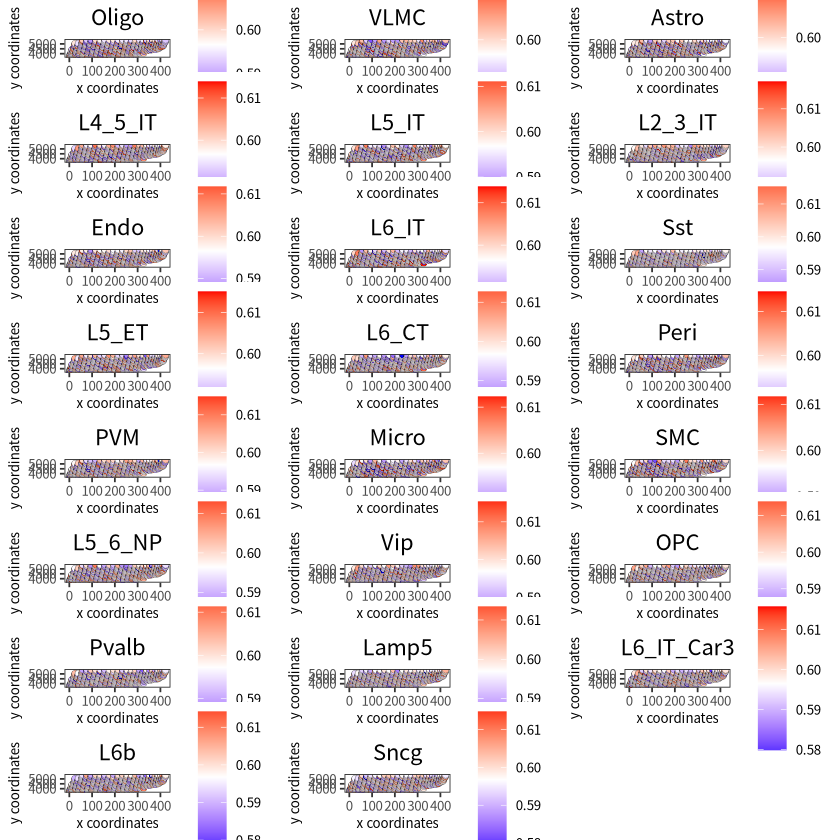

In [13]:
cell_types_subset = unique(cell_annotations)
spatCellPlot(gobject = my_giotto_object,
     spat_enr_names = 'rank',
     cell_annotation_values = cell_types_subset,
     cow_n_col = 3,coord_fix_ratio = NULL, point_size = 1.75)

In [38]:
# ============================================================
# Safe SpatialDWLS: robust implementation for Giotto objects
# ============================================================

library(Giotto)
library(Matrix)
library(quadprog)
library(data.table)

DWLS_EPS <- 1e-8

# ---------- 1. Safe initialization ----------
safe_ols_solution <- function(S, B, eps = DWLS_EPS) {
  B <- as.numeric(B)
  valid <- apply(S, 1, function(x) all(is.finite(x))) &
    is.finite(B) &
    rowSums(abs(S)) > eps
  
  S <- S[valid, , drop = FALSE]
  B <- B[valid]
  
  if (nrow(S) == 0 || ncol(S) == 0) {
    return(setNames(rep(1 / ncol(S), ncol(S)), colnames(S)))
  }
  
  solution <- tryCatch(
    as.numeric(Giotto:::solve_OLS_internal(S, matrix(B, ncol = 1))),
    error = function(e) rep(NA_real_, ncol(S))
  )
  
  # 原始 OLS 解无效、全零或负值占主导时，使用非负相关性初始化
  if (length(solution) != ncol(S) ||
      any(!is.finite(solution)) ||
      sum(pmax(solution, 0)) <= eps) {
    
    solution <- pmax(as.numeric(crossprod(S, B)), 0)
  } else {
    solution <- pmax(solution, 0)
  }
  
  # 若 marker 与该 spot 完全没有有效信号，则均匀初始化
  if (sum(solution) <= eps) {
    solution <- rep(1 / ncol(S), ncol(S))
  } else {
    solution <- solution / sum(solution)
  }
  
  names(solution) <- colnames(S)
  solution
}


# ---------- 2. Safe dampened weighted least squares ----------
solve_dampened_WLSj_safe <- function(S, B, goldStandard, j,
                                     eps = DWLS_EPS,
                                     max_weight = 1e8) {
  
  B <- as.numeric(B)
  goldStandard <- as.numeric(goldStandard)
  names(goldStandard) <- colnames(S)
  
  valid <- apply(S, 1, function(x) all(is.finite(x))) &
    is.finite(B) &
    rowSums(abs(S)) > eps
  
  S <- S[valid, , drop = FALSE]
  B <- B[valid]
  
  if (nrow(S) == 0 || ncol(S) == 0) {
    return(goldStandard)
  }
  
  goldStandard[!is.finite(goldStandard)] <- 0
  goldStandard <- pmax(goldStandard, 0)
  
  if (sum(goldStandard) <= eps) {
    goldStandard <- safe_ols_solution(S, B, eps)
  } else {
    goldStandard <- goldStandard / sum(goldStandard)
  }
  
  # 关键修复：
  # 原始代码 ws = 1/(S %*% sol)^2。
  # 当 S %*% sol = 0 时，ws = Inf，随后 Inf/Inf = NaN。
  predicted_expr <- as.vector(S %*% goldStandard)
  predicted_expr[!is.finite(predicted_expr) | predicted_expr <= eps] <- eps
  
  ws <- 1 / (predicted_expr ^ 2)
  ws[!is.finite(ws)] <- max_weight
  ws <- pmin(ws, max_weight)
  
  min_ws <- min(ws[is.finite(ws) & ws > 0])
  if (!is.finite(min_ws) || min_ws <= 0) {
    return(goldStandard)
  }
  
  ws_scaled <- ws / min_ws
  multiplier <- 2^(j - 1)
  ws_dampened <- pmin(ws_scaled, multiplier)
  ws_dampened[!is.finite(ws_dampened) | ws_dampened <= 0] <- 1
  
  W <- diag(ws_dampened, nrow = length(ws_dampened))
  D <- t(S) %*% W %*% S
  d <- as.numeric(t(S) %*% W %*% B)
  
  # 数值稳定化
  D <- (D + t(D)) / 2
  sc <- tryCatch(norm(D, "2"), error = function(e) NA_real_)
  
  if (!is.finite(sc) || sc <= eps || any(!is.finite(D)) || any(!is.finite(d))) {
    return(goldStandard)
  }
  
  D_scaled <- D / sc
  d_scaled <- d / sc
  
  D_pd <- tryCatch(
    as.matrix(Matrix::nearPD(D_scaled, ensureSymmetry = TRUE)$mat),
    error = function(e) NULL
  )
  
  if (is.null(D_pd) || any(!is.finite(D_pd))) {
    return(goldStandard)
  }
  
  # 防止 quadprog 因边界特征值失败
  D_pd <- (D_pd + t(D_pd)) / 2 + diag(eps, ncol(D_pd))
  
  qp_solution <- tryCatch(
    quadprog::solve.QP(
      Dmat = D_pd,
      dvec = d_scaled,
      Amat = diag(ncol(S)),
      bvec = rep(0, ncol(S))
    )$solution,
    error = function(e) NULL
  )
  
  if (is.null(qp_solution) || any(!is.finite(qp_solution))) {
    return(goldStandard)
  }
  
  qp_solution <- pmax(qp_solution, 0)
  
  if (sum(qp_solution) <= eps) {
    return(goldStandard)
  }
  
  qp_solution <- qp_solution / sum(qp_solution)
  names(qp_solution) <- colnames(S)
  qp_solution
}


# ---------- 3. Safe iterative DWLS ----------
optimize_solveDampenedWLS_safe <- function(S, B, constant_J,
                                           eps = DWLS_EPS,
                                           max_iter = 1000) {
  
  solution <- safe_ols_solution(S, B, eps)
  
  for (iteration in seq_len(max_iter)) {
    new_solution <- solve_dampened_WLSj_safe(
      S = S,
      B = B,
      goldStandard = solution,
      j = constant_J,
      eps = eps
    )
    
    # 与原函数含义一致：新解占 20%，旧解占 80%
    solution_average <- 0.2 * new_solution + 0.8 * solution
    solution_average <- pmax(solution_average, 0)
    
    if (sum(solution_average) <= eps) break
    
    solution_average <- solution_average / sum(solution_average)
    change <- sqrt(sum((solution_average - solution)^2))
    solution <- solution_average
    
    if (!is.finite(change) || change < 0.01) break
  }
  
  names(solution) <- colnames(S)
  solution
}


# ---------- 4. Safe spot-level deconvolution ----------
spot_deconvolution_safe <- function(expr, cluster_info, ct_exp, binary_matrix,
                                    eps = DWLS_EPS) {
  
  cluster_info <- as.vector(cluster_info)
  cluster_sort <- sort(unique(cluster_info[!is.na(cluster_info)]))
  
  # 每个基因仅归属到 signature 表达最高的一个 cell type
  enrich_matrix <- matrix(
    0,
    nrow = nrow(ct_exp),
    ncol = ncol(ct_exp),
    dimnames = dimnames(ct_exp)
  )
  
  max_type_index <- max.col(ct_exp, ties.method = "first")
  enrich_matrix[cbind(seq_len(nrow(ct_exp)), max_type_index)] <- 1
  
  dwls_results <- matrix(
    0,
    nrow = ncol(ct_exp),
    ncol = ncol(expr),
    dimnames = list(colnames(ct_exp), colnames(expr))
  )
  
  for (cluster_i in cluster_sort) {
    spot_index <- which(cluster_info == cluster_i)
    if (length(spot_index) == 0) next
    
    cluster_i_matrix <- binary_matrix[, spot_index, drop = FALSE]
    candidate_types <- rownames(cluster_i_matrix)[rowSums(cluster_i_matrix > 0) > 0]
    
    if (length(candidate_types) == 0) next
    
    # 仅一个候选 cell type，直接赋值为 1
    if (length(candidate_types) == 1) {
      dwls_results[candidate_types, spot_index] <- 1
      next
    }
    
    marker_genes <- unique(unlist(lapply(candidate_types, function(cell_type) {
      rownames(enrich_matrix)[enrich_matrix[, cell_type] == 1]
    })))
    
    common_genes <- intersect(rownames(expr), marker_genes)
    if (length(common_genes) < 2) next
    
    select_sig_exp <- ct_exp[common_genes, candidate_types, drop = FALSE]
    cluster_expr <- expr[common_genes, spot_index, drop = FALSE]
    
    # 用 cluster 平均表达估计 dampening constant
    all_exp <- rowMeans(cluster_expr)
    init_all <- safe_ols_solution(select_sig_exp, all_exp, eps)
    
    constant_J <- tryCatch(
      Giotto:::find_dampening_constant(select_sig_exp, all_exp, init_all),
      error = function(e) 1
    )
    
    if (!is.finite(constant_J) || constant_J <= 0) constant_J <- 1
    
    for (spot_name in colnames(cluster_expr)) {
      B <- as.numeric(cluster_expr[, spot_name])
      names(B) <- rownames(cluster_expr)
      
      spot_candidate_types <- rownames(cluster_i_matrix)[
        cluster_i_matrix[, spot_name] > 0
      ]
      
      if (length(spot_candidate_types) == 0) next
      
      if (length(spot_candidate_types) == 1) {
        dwls_results[spot_candidate_types, spot_name] <- 1
        next
      }
      
      spot_marker_genes <- unique(unlist(lapply(spot_candidate_types, function(cell_type) {
        rownames(enrich_matrix)[enrich_matrix[, cell_type] == 1]
      })))
      
      spot_genes <- intersect(rownames(ct_exp), spot_marker_genes)
      spot_genes <- intersect(spot_genes, names(B))
      
      if (length(spot_genes) < 2) next
      
      S_k <- ct_exp[spot_genes, spot_candidate_types, drop = FALSE]
      B_k <- B[spot_genes]
      
      # 所选 marker gene 在该 spot 完全没有表达，跳过
      if (sum(B_k > eps, na.rm = TRUE) == 0) next
      
      sol_dwls <- optimize_solveDampenedWLS_safe(
        S = S_k,
        B = B_k,
        constant_J = constant_J,
        eps = eps
      )
      
      dwls_results[names(sol_dwls), spot_name] <- sol_dwls
    }
  }
  
  dwls_results[!is.finite(dwls_results)] <- 0
  dwls_results[dwls_results < 0] <- 0
  
  # 每个 spot 的比例归一化
  spot_sum <- colSums(dwls_results)
  valid_spot <- spot_sum > eps
  dwls_results[, valid_spot] <- sweep(
    dwls_results[, valid_spot, drop = FALSE],
    2,
    spot_sum[valid_spot],
    "/"
  )
  
  dwls_results
}


# ---------- 5. Safe Giotto wrapper ----------
runDWLSDeconv_safe <- function(gobject,
                                sign_matrix,
                                cluster_column = "hier_clus",
                                expression_values = "normalized",
                                logbase = 2,
                                n_cell = 5,
                                cutoff = 2,
                                name = "DWLS_safe",
                                return_gobject = TRUE,
                                eps = DWLS_EPS) {
  
  expr_values <- Giotto:::select_expression_values(
    gobject = gobject,
    values = expression_values
  )
  
  cell_metadata <- Giotto::pDataDT(gobject)
  if (!cluster_column %in% colnames(cell_metadata)) {
    stop("cluster_column not found: ", cluster_column)
  }
  
  cluster <- cell_metadata[[cluster_column]]
  if (length(cluster) != ncol(expr_values)) {
    stop("cluster_column length must equal the number of spatial spots.")
  }
  
  sign_matrix <- as.matrix(sign_matrix)
  storage.mode(sign_matrix) <- "double"
  
  if (is.null(rownames(sign_matrix)) || is.null(colnames(sign_matrix))) {
    stop("sign_matrix must have gene row names and cell-type column names.")
  }
  
  # DWLS 需要非负表达 signature
  sign_matrix[!is.finite(sign_matrix)] <- 0
  sign_matrix[sign_matrix < 0] <- 0
  
  # 与原 Giotto 实现相同：从 log2 normalized 值还原
  nolog_expr <- logbase^(expr_values) - 1
  nolog_expr[!is.finite(nolog_expr) | nolog_expr < 0] <- 0
  
  common_genes <- intersect(rownames(sign_matrix), rownames(nolog_expr))
  if (length(common_genes) < 10) {
    stop("Too few overlapping genes: ", length(common_genes))
  }
  
  filter_sig <- sign_matrix[common_genes, , drop = FALSE]
  filter_expr <- nolog_expr[common_genes, , drop = FALSE]
  filter_log_expr <- expr_values[common_genes, , drop = FALSE]
  
  # 去除无信息基因与无信息 cell type
  valid_gene <- rowSums(filter_sig) > eps
  filter_sig <- filter_sig[valid_gene, , drop = FALSE]
  filter_expr <- filter_expr[rownames(filter_sig), , drop = FALSE]
  filter_log_expr <- filter_log_expr[rownames(filter_sig), , drop = FALSE]
  
  valid_type <- colSums(filter_sig) > eps
  filter_sig <- filter_sig[, valid_type, drop = FALSE]
  
  if (nrow(filter_sig) < 10 || ncol(filter_sig) < 2) {
    stop("After filtering, signature matrix has too few genes or cell types.")
  }
  
  message(
    "DWLS-safe uses ", nrow(filter_sig), " common genes and ",
    ncol(filter_sig), " cell types."
  )
  
  enrich_proportion <- Giotto:::enrich_deconvolution(
    expr = filter_expr,
    log_expr = filter_log_expr,
    cluster_info = cluster,
    ct_exp = filter_sig,
    cutoff = cutoff
  )
  
  resolution <- 1 / n_cell
  binarize_proportion <- ifelse(enrich_proportion >= resolution, 1, 0)
  binarize_proportion[!is.finite(binarize_proportion)] <- 0
  
  spot_proportion <- spot_deconvolution_safe(
    expr = filter_expr,
    cluster_info = cluster,
    ct_exp = filter_sig,
    binary_matrix = binarize_proportion,
    eps = eps
  )
  
  deconvolutionDT <- data.table(
    cell_ID = colnames(spot_proportion)
  )
  deconvolutionDT <- cbind(
    deconvolutionDT,
    as.data.table(t(spot_proportion))
  )
  
  if (!return_gobject) return(deconvolutionDT)
  
  gobject@spatial_enrichment[[name]] <- deconvolutionDT
  gobject
}


# ============================================================
# Run: start with cutoff = 2, not 0
# ============================================================

my_giotto_object <- runDWLSDeconv_safe(
  gobject = my_giotto_object,
  sign_matrix = signature_matrix,
  cluster_column = "hier_clus",
  expression_values = "normalized",
  logbase = 2,
  cutoff = 2,
  n_cell = 5,
  name = "DWLS_safe"
)

# Results:
head(my_giotto_object@spatial_enrichment$DWLS_safe)

DWLS-safe uses 248 common genes and 23 cell types.



[1] 21
[1] 17
[1] 87
[1] 26
[1] 19
[1] 10
[1] 10
[1] 9
[1] 5
[1] 1
[1] 3
[1] 11
[1] 6
[1] 4
[1] 5
[1] 5
[1] 1
[1] 2
[1] 4
[1] 1
[1] 1


cell_ID,Astro,Endo,L2_3_IT,L4_5_IT,L5_6_NP,L5_ET,L5_IT,L6_CT,L6_IT,⋯,OPC,Oligo,PVM,Peri,Pvalb,SMC,Sncg,Sst,VLMC,Vip
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X0,0.0000000,0.0000000,0,0,0,0,0,0,0,⋯,0,0,0.0000000,1,0,0,0,0,0,0
X1,0.3326577,0.6673423,0,0,0,0,0,0,0,⋯,0,0,0.0000000,0,0,0,0,0,0,0
X2,1.0000000,0.0000000,0,0,0,0,0,0,0,⋯,0,0,0.0000000,0,0,0,0,0,0,0
X3,0.5075501,0.0000000,0,0,0,0,0,0,0,⋯,0,0,0.4924499,0,0,0,0,0,0,0
X4,0.0000000,0.0000000,0,0,0,0,0,0,0,⋯,0,0,1.0000000,0,0,0,0,0,0,0
X5,0.0000000,0.0000000,0,0,0,0,0,0,0,⋯,0,0,0.0000000,0,0,0,0,0,1,0


Number of spots:  424 
Number of cell types:  23 
Cell types:
 [1] "Astro"      "Endo"       "L2_3_IT"    "L4_5_IT"    "L5_6_NP"   
 [6] "L5_ET"      "L5_IT"      "L6_CT"      "L6_IT"      "L6_IT_Car3"
[11] "L6b"        "Lamp5"      "Micro"      "OPC"        "Oligo"     
[16] "PVM"        "Peri"       "Pvalb"      "SMC"        "Sncg"      
[21] "Sst"        "VLMC"       "Vip"       

Any NA:  FALSE 
Any Inf:  FALSE 
Minimum proportion:  0 
Maximum proportion:  1 

Spot-level proportion sums:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  1.0000  1.0000  0.9528  1.0000  1.0000 
Valid spots with nonzero deconvolution:  404 / 424 
   cell_ID dominant_cell_type dominant_proportion
    <char>             <char>               <num>
1:      X0               Peri           1.0000000
2:      X1               Endo           0.6673423
3:      X2              Astro           1.0000000
4:      X3              Astro           0.5075501
5:      X4                PVM           1.0000000
6: 


Saved successfully to: /home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS



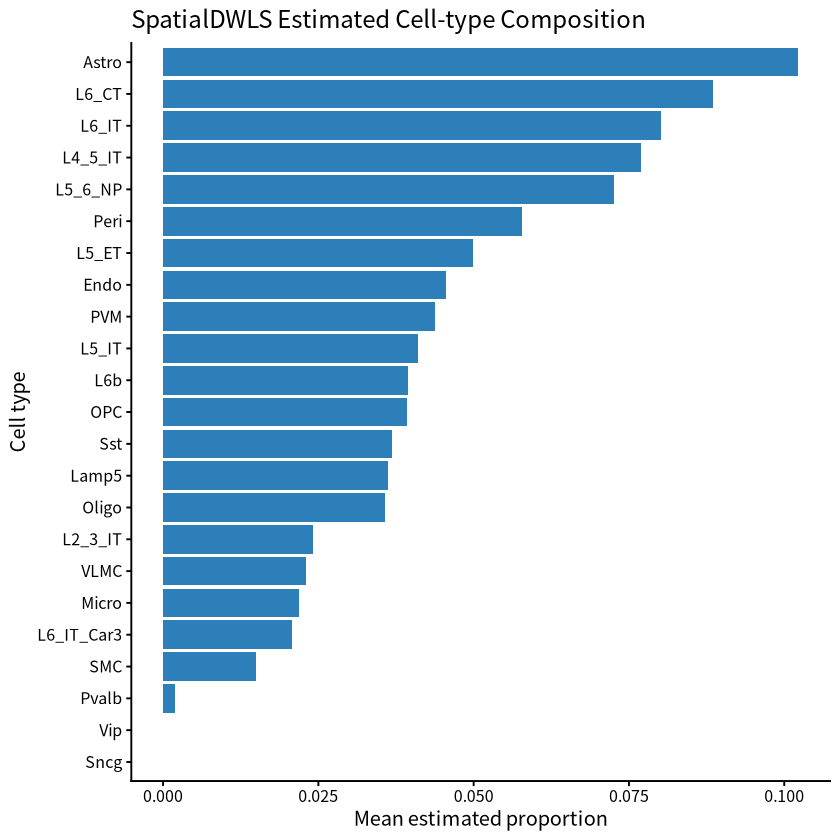

In [39]:
# ============================================================
# Post-DWLS: result check, export, and optional evaluation
# ============================================================

library(data.table)
library(ggplot2)

# ---------- 1. Extract deconvolution result ----------
dwls_result <- as.data.table(
  my_giotto_object@spatial_enrichment$DWLS_safe
)

stopifnot("cell_ID" %in% colnames(dwls_result))

cell_type_columns <- setdiff(colnames(dwls_result), "cell_ID")

dwls_matrix <- as.matrix(dwls_result[, ..cell_type_columns])
rownames(dwls_matrix) <- dwls_result$cell_ID
storage.mode(dwls_matrix) <- "double"

# ---------- 2. Basic validity checks ----------
cat("Number of spots: ", nrow(dwls_matrix), "\n")
cat("Number of cell types: ", ncol(dwls_matrix), "\n")
cat("Cell types:\n")
print(colnames(dwls_matrix))

cat("\nAny NA: ", anyNA(dwls_matrix), "\n")
cat("Any Inf: ", any(is.infinite(dwls_matrix)), "\n")
cat("Minimum proportion: ", min(dwls_matrix), "\n")
cat("Maximum proportion: ", max(dwls_matrix), "\n")

spot_sum <- rowSums(dwls_matrix)

cat("\nSpot-level proportion sums:\n")
print(summary(spot_sum))

valid_spot <- spot_sum > 0
cat("Valid spots with nonzero deconvolution: ",
    sum(valid_spot), "/", nrow(dwls_matrix), "\n")

if (any(abs(spot_sum[valid_spot] - 1) > 1e-5)) {
  warning("Some valid spots do not sum to 1. Re-normalizing them now.")
  
  dwls_matrix[valid_spot, ] <- sweep(
    dwls_matrix[valid_spot, , drop = FALSE],
    1,
    spot_sum[valid_spot],
    "/"
  )
  
  dwls_result[, (cell_type_columns) := as.data.table(dwls_matrix)]
  my_giotto_object@spatial_enrichment$DWLS_safe <- dwls_result
}

# ---------- 3. Dominant cell type per spot ----------
dominant_cell_type <- rep(NA_character_, nrow(dwls_matrix))

if (any(valid_spot)) {
  dominant_cell_type[valid_spot] <- colnames(dwls_matrix)[
    max.col(dwls_matrix[valid_spot, , drop = FALSE], ties.method = "first")
  ]
}

dominant_result <- data.table(
  cell_ID = rownames(dwls_matrix),
  dominant_cell_type = dominant_cell_type,
  dominant_proportion = apply(dwls_matrix, 1, max)
)

print(head(dominant_result))

cat("\nDominant cell-type counts:\n")
print(sort(table(dominant_result$dominant_cell_type), decreasing = TRUE))

# ---------- 4. Create long-format table for plotting ----------
dwls_long <- melt(
  as.data.table(dwls_matrix, keep.rownames = "cell_ID"),
  id.vars = "cell_ID",
  variable.name = "cell_type",
  value.name = "proportion"
)

# Average estimated composition across all spots
average_composition <- dwls_long[
  ,
  .(mean_proportion = mean(proportion, na.rm = TRUE)),
  by = cell_type
][order(-mean_proportion)]

print(average_composition)

# ---------- 5. Plot global cell-type composition ----------
composition_plot <- ggplot(
  average_composition,
  aes(x = reorder(cell_type, mean_proportion), y = mean_proportion)
) +
  geom_col(fill = "#2C7FB8") +
  coord_flip() +
  labs(
    title = "SpatialDWLS Estimated Cell-type Composition",
    x = "Cell type",
    y = "Mean estimated proportion"
  ) +
  theme_classic(base_size = 12)

print(composition_plot)

# ---------- 6. Save outputs ----------
output_dir <- "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS"
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

fwrite(
  dwls_result,
  file.path(output_dir, "spatialDWLS_safe_deconvolution.csv")
)

fwrite(
  dominant_result,
  file.path(output_dir, "spatialDWLS_safe_dominant_cell_type.csv")
)

fwrite(
  average_composition,
  file.path(output_dir, "spatialDWLS_safe_mean_composition.csv")
)

ggsave(
  filename = file.path(output_dir, "spatialDWLS_safe_mean_composition.pdf"),
  plot = composition_plot,
  width = 7,
  height = 5
)

saveRDS(
  my_giotto_object,
  file.path(output_dir, "my_giotto_object_DWLS_safe.rds")
)

message("\nSaved successfully to: ", output_dir)

# ---------- 7. Optional: evaluate against ground truth ----------
# 仅当你已有 ground_truth_matrix 时运行。
# 要求：行是 spot，列是 cell type，且比例和为 1。
#
# common_spots <- intersect(rownames(dwls_matrix), rownames(ground_truth_matrix))
# common_types <- intersect(colnames(dwls_matrix), colnames(ground_truth_matrix))
#
# prediction <- dwls_matrix[common_spots, common_types, drop = FALSE]
# ground_truth <- ground_truth_matrix[common_spots, common_types, drop = FALSE]
#
# # spot × cell type 的整体误差
# mae <- mean(abs(prediction - ground_truth))
# rmse <- sqrt(mean((prediction - ground_truth)^2))
#
# # 每个 cell type 的 Pearson correlation
# cell_type_pcc <- sapply(common_types, function(cell_type) {
#   cor(
#     prediction[, cell_type],
#     ground_truth[, cell_type],
#     method = "pearson",
#     use = "complete.obs"
#   )
# })
#
# evaluation_result <- data.table(
#   cell_type = names(cell_type_pcc),
#   Pearson_correlation = as.numeric(cell_type_pcc)
# )
#
# cat("MAE: ", mae, "\n")
# cat("RMSE: ", rmse, "\n")
# print(evaluation_result[order(-Pearson_correlation)])
#
# fwrite(
#   evaluation_result,
#   file.path(output_dir, "spatialDWLS_safe_evaluation_by_cell_type.csv")
# )

In [14]:
markersall=read.table('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/makers_zztry.txt',sep='\t',header=T)

In [15]:
# 筛选条件
selected <- markersall[markersall$p_val_adj < 0.05 & markersall$avg_log2FC > 0, ]

# 按 cluster 分组，提取基因名称
marker_genes_per_cluster <- split(selected$gene, selected$cluster)

In [16]:
# 假设 marker_genes_per_cluster 是之前生成的命名列表
# 只保留基因长度大于 0 的 cluster
sign_list <- marker_genes_per_cluster[lengths(marker_genes_per_cluster) > 0]
sign_names <- names(sign_list)

# 生成签名矩阵（需加载 Giotto 或相关包）
signature_matrix <- makeSignMatrixPAGE(
    sign_names = sign_names,
    sign_list = sign_list
)

# 查看结果
dim(signature_matrix)
colnames(signature_matrix)  # 显示签名名称

[1] 248  23

[1] "Astro"      "Endo"       "L2_3_IT"    "L4_5_IT"    "L5_6_NP"   
 [6] "L5_ET"      "L5_IT"      "L6_CT"      "L6_IT"      "L6_IT_Car3"
[11] "L6b"        "Lamp5"      "Micro"      "OPC"        "Oligo"     
[16] "PVM"        "Peri"       "Pvalb"      "SMC"        "Sncg"      
[21] "Sst"        "VLMC"       "Vip"

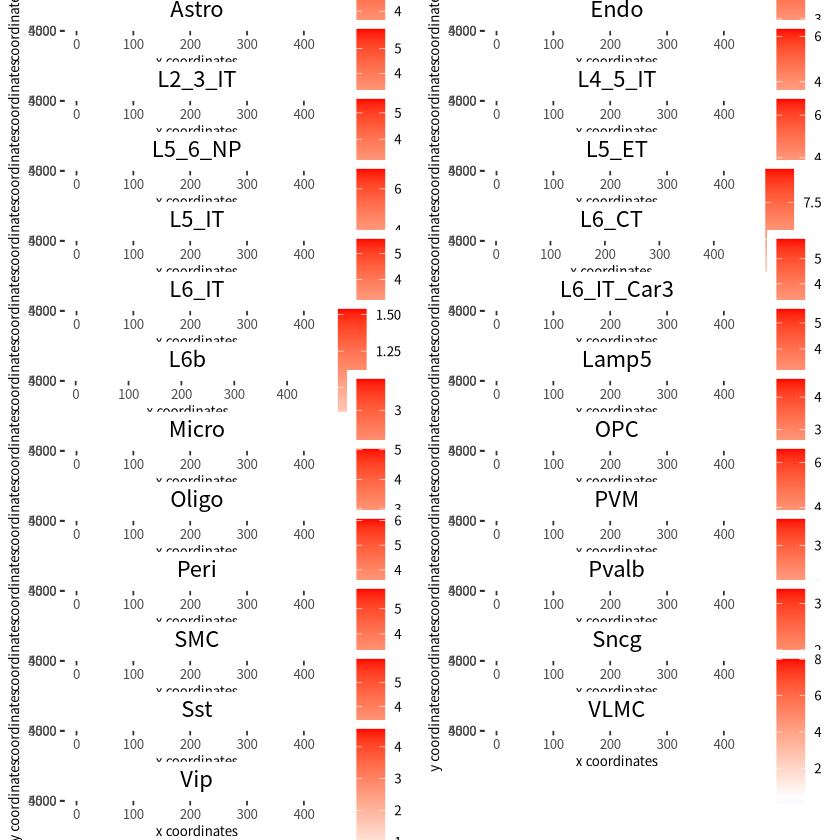

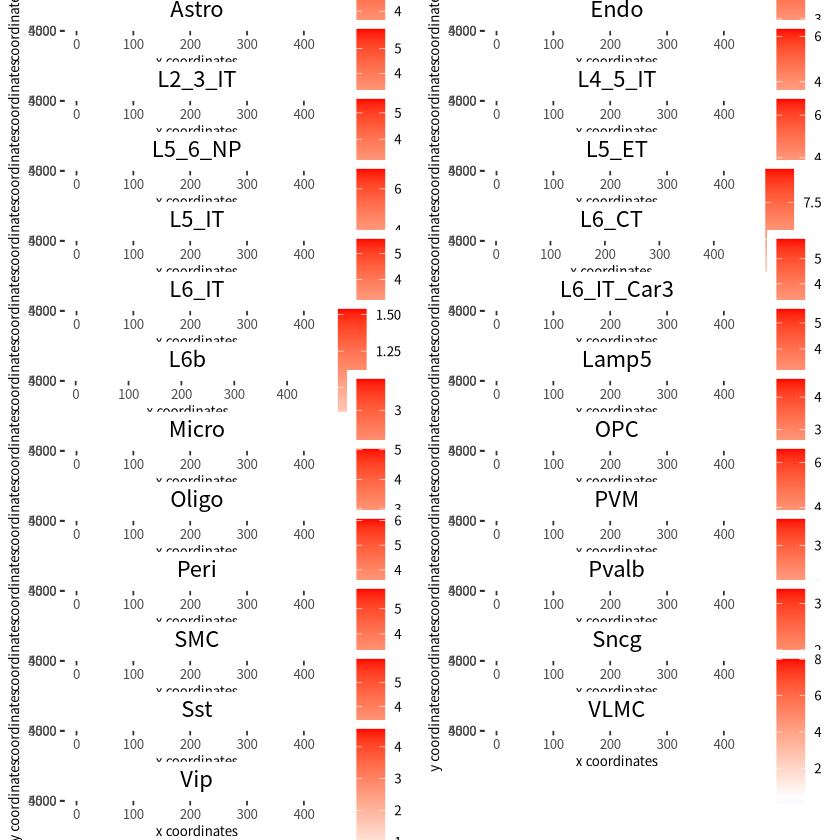

In [17]:
my_giotto_object = runHyperGeometricEnrich(gobject = my_giotto_object,
                   sign_matrix = signature_matrix)

cell_types_subset = colnames(signature_matrix)
spatCellPlot(gobject = my_giotto_object,
     spat_enr_names = 'hypergeometric',
     cell_annotation_values = cell_types_subset,
     cow_n_col = 2,coord_fix_ratio = NULL, point_size = 2.75)

In [18]:
saveRDS(my_giotto_object, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS/my_giotto_object_merfish_zztry.rds")
saveRDS(signature_matrix, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS/signature_matrix_merfish_zztry.rds")

In [19]:
my_giotto_object=readRDS(file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS/my_giotto_object_merfish_zztry.rds")
signature_matrix=readRDS(file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS/signature_matrix_merfish_zztry.rds")

In [20]:
enrich_analysis_safe <- function (expr_values, sign_matrix) 
{
    interGene <- intersect(rownames(sign_matrix), rownames(expr_values))
    filterSig <- sign_matrix[interGene, ]
    mean_gene_expr <- log2(rowMeans(2^expr_values - 1, dims = 1) + 1)
    geneFold <- expr_values - mean_gene_expr
    cellColMean <- apply(geneFold, 2, mean)
    cellColSd <- apply(geneFold, 2, stats::sd)
    enrichment <- matrix(NA, nrow = ncol(filterSig), ncol = length(cellColMean))
    for (i in 1:ncol(filterSig)) {
        signames <- rownames(filterSig)[which(filterSig[, i] == 1)]
        if (length(signames) == 0) {
            # 没有标记基因，跳过（或赋NA）
            next
        }
        # 关键修改：确保 geneFold[signames, ] 始终是矩阵
        print(length(signames))
        sub_geneFold <- geneFold[signames, , drop = FALSE]  # drop=FALSE 防止降维
        sigColMean <- apply(sub_geneFold, 2, mean)
        m <- length(signames)
        zscore <- (sigColMean - cellColMean) * sqrt(m) / cellColSd
        enrichment[i, ] <- zscore
    }
    rownames(enrichment) <- colnames(filterSig)
    colnames(enrichment) <- names(cellColMean)
    return(enrichment)
}

In [21]:
common_genes <- intersect(
  rownames(expr_values),
  rownames(signature_matrix)
)

ERROR: Error: 找不到对象'expr_values'


In [24]:
assignInNamespace("enrich_analysis", enrich_analysis_safe, ns = "Giotto")

In [26]:
my_giotto_object <- runDWLSDeconv(
  gobject = my_giotto_object,
  sign_matrix = signature_matrix,
  cluster_column = "hier_clus",
  cutoff = 2,
  n_cell = 5
)

[1] "The 248 overlapped genes between signature matrix and\nspatial expression profile"
[1] 21
[1] 17
[1] 87
[1] 26
[1] 19
[1] 10
[1] 10
[1] 9
[1] 5
[1] 1
[1] 3
[1] 11
[1] 6
[1] 4
[1] 5
[1] 5
[1] 1
[1] 2
[1] 4
[1] 1
[1] 1


ERROR: Error in eigen(if (doDykstra) R else Y, symmetric = TRUE): 'x'里有无穷值或缺失值


In [28]:
stopifnot(all(is.finite(signature_matrix)))
stopifnot(all(signature_matrix >= 0))

In [25]:
my_giotto_object = runDWLSDeconv(gobject = my_giotto_object, sign_matrix = signature_matrix, cluster_column = "hier_clus",cutoff = 0,n_cell = 5)

In [29]:
gobject=my_giotto_object;sign_matrix = signature_matrix;cluster_column = "hier_clus";cutoff = 0

In [30]:
Giotto:::package_check(pkg_name = "quadprog", repository = "CRAN")
name=NULL
logbase = 2
expression_values = c("normalized")
    if (is.null(name)) 
        name = "DWLS"
    values = match.arg(expression_values, c("normalized", "scaled", 
        "custom"))
    expr_values = Giotto:::select_expression_values(gobject = gobject, 
        values = values)
    nolog_expr = logbase^(expr_values) - 1
    cell_metadata = pDataDT(gobject)
    if (!cluster_column %in% colnames(cell_metadata)) {
        stop("\n cluster column not found \n")
    }
    cluster = cell_metadata[[cluster_column]]
    sign_matrix <- as.matrix(sign_matrix)
    intersect_gene = intersect(rownames(sign_matrix), rownames(nolog_expr))
    filter_Sig = sign_matrix[intersect_gene, ]
    filter_expr = nolog_expr[intersect_gene, ]
    filter_log_expr = expr_values[intersect_gene, ]
    if (length(intersect_gene) < 10) {
        stop(paste0("The overlapped genes between signature matrix and spatial expression profile is too small. (", 
            length(intersect_gene), " overlapped genes)"))
    }else {
        print(paste0("The ", length(intersect_gene), " overlapped genes between signature matrix and\nspatial expression profile"))
    }

[1] TRUE

[1] "The 248 overlapped genes between signature matrix and\nspatial expression profile"


In [31]:
enrich_spot_proportion <- Giotto:::enrich_deconvolution(expr = filter_expr, 
        log_expr = filter_log_expr, cluster_info = cluster, ct_exp = filter_Sig, 
        cutoff = cutoff)

[1] 21
[1] 17
[1] 87
[1] 26
[1] 19
[1] 10
[1] 10
[1] 9
[1] 5
[1] 1
[1] 3
[1] 11
[1] 6
[1] 4
[1] 5
[1] 5
[1] 1
[1] 2
[1] 4
[1] 1
[1] 1


In [23]:
solution <- Giotto:::solve_OLS_internal(S_k, B[uniq_ct_k_gene, ])

predicted_expr <- as.vector(S_k %*% solution)

cat("solution:\n")
print(solution)

cat("Number of non-positive predicted genes:",
    sum(!is.finite(predicted_expr) | predicted_expr <= 1e-12), "\n")

summary(predicted_expr)

ERROR: Error: 找不到对象'S_k'


In [32]:
n_cell = 5
resolution = (1/n_cell)
binarize_proportion = ifelse(enrich_spot_proportion >= resolution, 
        1, 0)

In [33]:
expr = filter_expr;cluster_info = cluster; ct_exp = filter_Sig; binary_matrix = binarize_proportion

In [34]:
enrich_matrix <- matrix(0, nrow = dim(ct_exp)[1], ncol = dim(ct_exp)[2])
    rowmax_col <- Rfast::rowMaxs(ct_exp)

In [35]:
for (i in 1:length(rowmax_col)) {
        enrich_matrix[i, rowmax_col[i]] = 1
    }

In [36]:
    rownames(enrich_matrix) <- rownames(ct_exp)
    colnames(enrich_matrix) <- colnames(ct_exp)
    cluster_sort <- sort(unique(cluster_info))
    dwls_results <- matrix(0, nrow = dim(ct_exp)[2], ncol = dim(expr)[2])
    rownames(dwls_results) <- colnames(ct_exp)
    colnames(dwls_results) <- colnames(expr)

In [37]:
   for (i in 1:length(cluster_sort)) {
        cluster_i_matrix <- binary_matrix[, which(cluster_info == 
            cluster_sort[i])]
        row_i_max <- Rfast::rowMaxs(cluster_i_matrix, value = TRUE)
        ct_i <- rownames(cluster_i_matrix)[which(row_i_max == 
            1)]
        if (length(ct_i) == 1) {
            dwls_results[ct_i[1], which(cluster_info == cluster_sort[i])] == 
                1
        }
        else {
            ct_gene <- c()
            for (j in 1:length(ct_i)) {
                sig_gene_j <- rownames(enrich_matrix)[which(enrich_matrix[, 
                  ct_i[j]] == 1)]
                ct_gene <- c(ct_gene, sig_gene_j)
            }
            uniq_ct_gene <- intersect(rownames(expr), unique(ct_gene))
            select_sig_exp <- ct_exp[uniq_ct_gene, ct_i]
            cluster_i_cell <- which(cluster_info == cluster_sort[i])
            cluster_cell_exp <- expr[uniq_ct_gene, cluster_i_cell]
            all_exp <- rowMeans(cluster_cell_exp)
            solution_all_exp <- Giotto:::solve_OLS_internal(select_sig_exp, 
                all_exp)
            if (length(all_exp) >= 4) {
                constant_J <- Giotto:::find_dampening_constant(select_sig_exp, 
                  all_exp, solution_all_exp)
                for (k in 1:(dim(cluster_cell_exp)[2])) {
                  B <- Matrix::as.matrix(cluster_cell_exp[, k])
                  ct_spot_k <- rownames(cluster_i_matrix)[which(cluster_i_matrix[, 
                    k] == 1)]
                  if (length(ct_spot_k) == 1) {
                    dwls_results[ct_spot_k[1], colnames(cluster_cell_exp)[k]] <- 1
                  }
                  else if (length(ct_spot_k) == 0) {
                    NULL
                  }
                  else {
                    ct_k_gene <- c()
                    for (m in 1:length(ct_spot_k)) {
                      sig_gene_k <- rownames(enrich_matrix)[which(enrich_matrix[, 
                        ct_spot_k[m]] == 1)]
                      ct_k_gene <- c(ct_k_gene, sig_gene_k)
                    }
                    uniq_ct_k_gene <- intersect(rownames(ct_exp), 
                      unique(ct_k_gene))
                    S_k <- Matrix::as.matrix(ct_exp[uniq_ct_k_gene, 
                      ct_spot_k])
                    if (length(which(B != 0)) > 0) {
                      solDWLS <- Giotto:::optimize_solveDampenedWLS(S_k, 
                        B[uniq_ct_k_gene, ], constant_J)
                      dwls_results[names(solDWLS), colnames(cluster_cell_exp)[k]] <- solDWLS
                    }
                  }
                }
            }
        }
    }

ERROR: Error in eigen(if (doDykstra) R else Y, symmetric = TRUE): 'x'里有无穷值或缺失值


In [78]:
optimize_solveDampenedWLS

ERROR: Error: 找不到对象'optimize_solveDampenedWLS'


In [81]:

                        S=S_k; 
                        B=B[uniq_ct_k_gene, ]

In [83]:
solution <- Giotto:::solve_OLS_internal(S, B)
    iterations <- 0
    changes <- c()
    j <- constant_J
    change <- 1
    while (change > 0.01 & iterations < 1000) {
        newsolution <- Giotto:::solve_dampened_WLSj(S, B, solution, j)
        solutionAverage <- rowMeans(cbind(newsolution, matrix(solution, 
            nrow = length(solution), ncol = 4)))
        change <- norm(Matrix::as.matrix(solutionAverage - solution))
        solution <- solutionAverage
        iterations <- iterations + 1
        changes <- c(changes, change)
    }

ERROR: Error in eigen(if (doDykstra) R else Y, symmetric = TRUE): 'x'里有无穷值或缺失值


In [97]:
B

Acta2 Adamts4     Alk   Cdca7 Ceacam9 Col14a1 Col23a1   Cspg4  Fam84b   Foxp2 
      0       0       0       0       0       0       0       0       0       0 
   Gad1    Hpse    Lmo1    Lsp1     Ltf     Nhs  Nkain3   Npas1   Npsr1   Parm1 
      0       0       0       0       0       0       0       0       0       0 
 Pde11a  Pdgfra   Prox1   Rab3b    Reln    Rerg Slc32a1    Sox6     Sp8   Sulf1 
      0       0       0       0       0       0       0       0       0       0 
   Syt6  Teddm3 Ubash3b     Ust   Vipr2    Vwc2 
      0       0       0       0       0       0

In [89]:
goldStandard=solution

In [90]:
multiplier <- 1 * 2^(j - 1)
    sol <- goldStandard
    ws <- as.vector((1/(S %*% sol))^2)
    wsScaled <- ws/min(ws)
    wsDampened <- wsScaled
    wsDampened[which(wsScaled > multiplier)] <- multiplier
    W <- diag(wsDampened)
    D <- t(S) %*% W %*% S
    d <- t(S) %*% W %*% B
    A <- cbind(diag(dim(S)[2]))
    bzero <- c(rep(0, dim(S)[2]))
    sc <- norm(D, "2")

In [93]:
ws

[1] Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf
[20] Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf Inf

In [72]:
ct_k_gene <- c()
                    for (m in 1:length(ct_spot_k)) {
                      sig_gene_k <- rownames(enrich_matrix)[which(enrich_matrix[, 
                        ct_spot_k[m]] == 1)]
                      ct_k_gene <- c(ct_k_gene, sig_gene_k)
                    }

In [32]:
my_giotto_object@cell_metadata$cluster=my_giotto_object@cell_metadata$hier_clus

In [34]:
my_giotto_object@cell_metadata$cell_ID=c(0:423)

In [35]:
write.table(my_giotto_object@cell_metadata, file='/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS/Spot_cluster_zztry.txt',sep='\t',quote = F)

In [36]:
write.table(my_giotto_object@spatial_enrichment$DWLS,file = '/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatialDWLS/spatialDWLS_dec_zztry.csv',sep=',',quote = F,row.names = F)

In [86]:
getAnywhere("solve_dampened_WLSj")

A single object matching ‘solve_dampened_WLSj’ was found
It was found in the following places
  namespace:Giotto
with value

function (S, B, goldStandard, j) 
{
    multiplier <- 1 * 2^(j - 1)
    sol <- goldStandard
    ws <- as.vector((1/(S %*% sol))^2)
    wsScaled <- ws/min(ws)
    wsDampened <- wsScaled
    wsDampened[which(wsScaled > multiplier)] <- multiplier
    W <- diag(wsDampened)
    D <- t(S) %*% W %*% S
    d <- t(S) %*% W %*% B
    A <- cbind(diag(dim(S)[2]))
    bzero <- c(rep(0, dim(S)[2]))
    sc <- norm(D, "2")
    D_mat = Matrix::nearPD(D/sc)
    D_mat = as.matrix(D_mat$mat)
    solution <- quadprog::solve.QP(D_mat, d/sc, A, bzero)$solution
    names(solution) <- colnames(S)
    return(solution)
}
<bytecode: 0x63fefce312e0>
<environment: namespace:Giotto>